KPI 1 - Total de Ventas:
35761512.17

KPI 2 - Promedio de Ventas:
4898.837283561644

KPI 3 - Total de Órdenes:
7300

KPI 4 - Top Proveedores:


,monto
nombre_proveedor,
PETRAMAS S.A.C.,6268541.20
SERV AGUA POTAB Y ALCANT DE LIMA-SEDAPAL,1466679.30
TECNO REDES S.A,952565.86
GLOBAL FUEL S.A.,817003.83
GTD PERÚ S.A,466666.72
GRIFOS ESPINOZA S.A.,447448.57
DISTRIBUIDORA Y SERVICIOS CA & BI E.I.R.L,429884.20
INDUSTRIAL SUPPORT & ACCESORIES S.A.C.,405420.00
VASQUEZ OSORIO ENZO LEONARDO,352610.00



KPI 5 - Ventas por Mes:


,monto
mes_compra,
1,1910971.71
2,4021337.13
3,4304138.97
4,3850745.27
5,3874148.27
6,2374746.83
7,2191587.50
8,2938591.97
9,3281256.96



KPI 6 - Ventas por Departamento:


,monto
departamento,
Lima,35761512.17


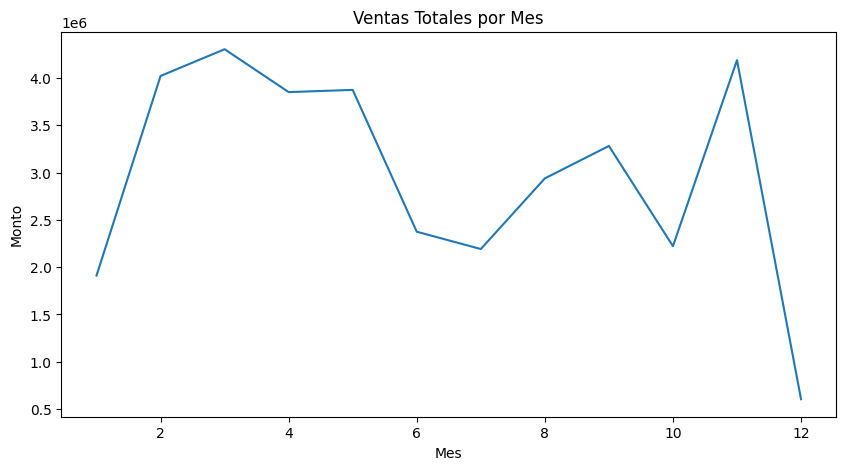

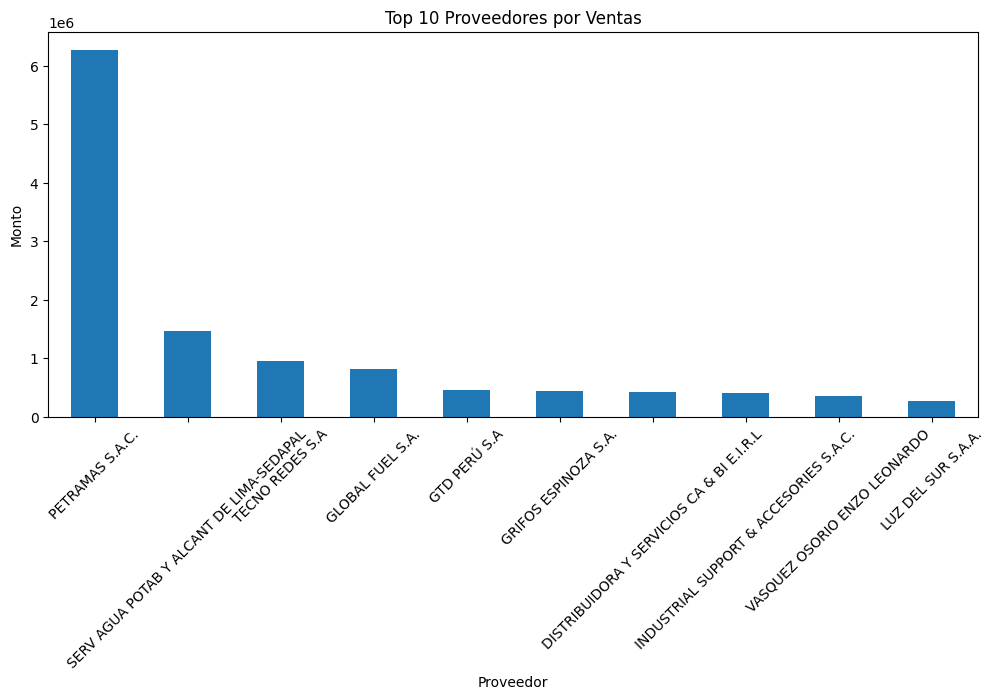

t_orden
SERVIVIOS    3780
SERVICIOS    3128
COMPRAS       392
Name: count, dtype: int64
Cantidad compras: 392
Cantidad servicios: 6908

VALIDACIÓN ESTADÍSTICA
Prueba utilizada: Mann-Whitney U
Estadístico U: 2025850.5
p-value: 1.1303740647909256e-61

Conclusión estadística:
Se rechaza H0. Existen diferencias significativas entre los montos de compras y servicios.


In [2]:

# ANÁLISIS DE KPIs Y VALIDACIÓN ESTADÍSTICA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

pd.set_option('display.max_columns', None)

# CARGA DEL DATASET
df = pd.read_csv('ventas_final.csv')


# LIMPIEZA BÁSICA
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace('á', 'a')
    .str.replace('é', 'e')
    .str.replace('í', 'i')
    .str.replace('ó', 'o')
    .str.replace('ú', 'u')
    .str.replace('ñ', 'n')
    .str.replace(' ', '_')
)

df['monto'] = pd.to_numeric(df['monto'], errors='coerce')

# KPI 1 - TOTAL DE VENTA
total_ventas = df['monto'].sum()

print("KPI 1 - Total de Ventas:")
print(total_ventas)

# KPI 2 - PROMEDIO DE VENTAS
promedio_ventas = df['monto'].mean()

print("\nKPI 2 - Promedio de Ventas:")
print(promedio_ventas)

# KPI 3 - TOTAL DE ÓRDENES
total_ordenes = df['t_orden'].count()

print("\nKPI 3 - Total de Órdenes:")
print(total_ordenes)

# KPI 4 - TOP 10 PROVEEDORES
top_proveedores = (
    df.groupby('nombre_proveedor')['monto']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nKPI 4 - Top Proveedores:")
display(top_proveedores)

# KPI 5 - VENTAS POR MES
ventas_mes = (
    df.groupby('mes_compra')['monto']
    .sum()
)

print("\nKPI 5 - Ventas por Mes:")
display(ventas_mes)

# KPI 6 - VENTAS POR DEPARTAMENTO
ventas_departamento = (
    df.groupby('departamento')['monto']
    .sum()
)

print("\nKPI 6 - Ventas por Departamento:")
display(ventas_departamento)


# VISUALIZACIÓN KPI TEMPORAL
plt.figure(figsize=(10,5))

ventas_mes.plot()

plt.title('Ventas Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Monto')

plt.show()


# VISUALIZACIÓN TOP PROVEEDORES
plt.figure(figsize=(12,5))

top_proveedores.plot(kind='bar')

plt.title('Top 10 Proveedores por Ventas')
plt.xlabel('Proveedor')
plt.ylabel('Monto')

plt.xticks(rotation=45)

plt.show()

# VALIDACIÓN ESTADÍSTICA
# Comparación de montos entre COMPRAS y SERVICIOS
from scipy.stats import mannwhitneyu

df['t_orden'] = df['t_orden'].astype(str).str.strip().str.upper()

print(df['t_orden'].value_counts())

compras = df[df['t_orden'].str.contains('COMPRA', na=False)]['monto'].dropna()
servicios = df[df['t_orden'].str.contains('SERV', na=False)]['monto'].dropna()

print("Cantidad compras:", len(compras))
print("Cantidad servicios:", len(servicios))

estadistico, p_value = mannwhitneyu(compras, servicios, alternative='two-sided')

print("\nVALIDACIÓN ESTADÍSTICA")
print("Prueba utilizada: Mann-Whitney U")
print("Estadístico U:", estadistico)
print("p-value:", p_value)

if p_value < 0.05:
    conclusion = "Se rechaza H0. Existen diferencias significativas entre los montos de compras y servicios."
else:
    conclusion = "No se rechaza H0. No existen diferencias significativas entre los montos de compras y servicios."

print("\nConclusión estadística:")
print(conclusion)

## Interpretación y Conclusiones Analíticas

Se realizó una validación estadística comparando los montos asociados a órdenes de tipo COMPRAS y SERVICIOS.

Hipótesis planteadas:

- H0: No existen diferencias significativas entre los montos de compras y servicios.
- H1: Existen diferencias significativas entre los montos de compras y servicios.

Debido a que las distribuciones presentan diferencias de tamaño y posible comportamiento no normal, se aplicó la prueba no paramétrica Mann-Whitney U.

Resultados obtenidos:

- Estadístico U: 2025850.5
- p-value: 1.13e-61

Interpretación:

El p-value obtenido es significativamente menor a 0.05, por lo que se rechaza la hipótesis nula (H0).

Esto indica que existen diferencias estadísticamente significativas entre los montos correspondientes a órdenes de compras y servicios.

Conclusión final:

Los registros analizados muestran comportamientos financieros distintos entre compras y servicios, lo cual evidencia patrones diferenciados en la ejecución presupuestal y contratación.